In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import glob
import os,shutil
import regex as re

In [3]:
# Using seaborn's style
plt.style.use(['ggplot', 'seaborn-whitegrid'])
WIDTH = 345

def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

config = {
    "figure.figsize": set_size(WIDTH),
    "grid.linestyle": '--',
    "hatch.color": '#eeeeee',
    "hatch.linewidth": 0.618,
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "Times New Roman",
#     "text.latex.unicode": True,
    "axes.unicode_minus": True,
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    # Make the label fonts a little smaller
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.handletextpad": 0.5,
    "legend.columnspacing": 1,
    "legend.numpoints": 3,
}

mpl.rcParams.update(config)
plt.rcParams['axes.edgecolor']='#333F4B'
plt.rcParams['axes.linewidth']=0.8

linestyle_tuple = [
     ('solid',        (0, ())),
     ('dotted',                (0, (1, 1))),
     ('long dash with offset', (5, (10, 3))),
     ('dashdotted',            (0, (3, 5, 1, 5))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),

     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]

/tmp/ipykernel_20993/1232656171.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(['ggplot', 'seaborn-whitegrid'])


In [6]:
def preprocess_result(sample_method):
    df = pd.read_csv(f"/ANOVA/RESULT_{sample_method}.csv") # need to change accordingly
    if sample_method == "stratified":
        df.alg = df.apply(lambda x: x.alg.replace(f"_{x.stratified_term}",""), axis=1)
    df = df[df.alg.isin(['aria-Aria_tpcc', 'calvin-Calvin_tpcc', 'cicada-Cicada_ycsb',
        'drtm_tpcc', 'gam_tpcc', 'herd_ycsb', 'janus-Janus_tpcc', 'mysql_tpcc', 
        'silo-Silo_tpcc', 'silo_ycsb', 'star_tpcc', 'star_ycsb','tapir_ycsb'])]
    # ,"silo_vs_partitionedstore","janus_vs_2pl"])]
    rename_alg = {
        'aria-Aria_tpcc':"Aria-TPC-C", 'calvin-Calvin_tpcc':"Calvin-TPC-C", 'cicada-Cicada_ycsb':"Cicada-YCSB",
        'drtm_tpcc':"DrTM-TPC-C", 'gam_tpcc':"GAM-TPC-C", 'herd_ycsb':"HERD-YCSB", 'janus-Janus_tpcc':"Janus-TPC-C", 'mysql_tpcc':"MySQL-TPC-C", 
        'silo-Silo_tpcc':"Silo-TPC-C", 'silo_ycsb':"Silo-YCSB", 'star_tpcc':"Star-TPC-C", 'star_ycsb':"Star-YCSB",
        'tapir_ycsb':'TAPIR-YCSB',"silo_vs_partitionedstore":"Silo/PartitionedStore-TPC-C","janus_vs_2pl":"Janus/2PL-TPC-C"} 
    df['alg'] = df['alg'].apply(lambda x:rename_alg[x])
    df["num_of_terms_changed"] *= 100
    df["num_turning_mismatch"] *= 100
    df['sample_ratio'] = df['sample_ratio'].apply(pd.to_numeric)
    df['random'] = df['random'].apply(pd.to_numeric)
    rename_alg_rev = {v: k for k, v in rename_alg.items()}
    df['sample_method'] = sample_method
    return df

In [7]:
df = pd.concat([preprocess_result(sample_method) for sample_method in ["random","stratified","balance","dist-aware"]],ignore_index=True)

In [ ]:
out_base = f"/ANOVA/plots/anova_r2" # need to change accordingly
if not os.path.exists(out_base):
    os.makedirs(out_base)

fig_size_one = set_size(WIDTH)

# fig, axs = plt.subplots(4, 3, figsize=(fig_size_one[0]*3,fig_size_one[1]*4),constrained_layout=True)
all_algs = df.alg.unique()
x_labels = [f"{i:.2f}" for i in np.arange(0.05, 1, 0.05)]
for idx, alg_name in enumerate(all_algs):
    # ax = axs[idx//3][idx%3]
    fig, ax = plt.subplots(1, 1, figsize=fig_size_one,constrained_layout=True)
    sns.lineplot(data=df[df.alg==alg_name],
                 x="sample_ratio",
                 y="r2_unsample",
                 estimator="median",
                 palette="Set1",
                 errorbar=("pi",60), 
                 err_style="bars",
                 ax=ax,
                 dashes=True, 
                 hue="sample_method",
                 style = "sample_method",
                 ms = 1, mew = 2, 
                 linewidth=1.0)
    ax.set_xticks(np.arange(0.05, 1, 0.05))
    ax.set_xticklabels(x_labels,rotation=30)
    ax.set_xlabel("Sampling Rate")
    ax.set_ylabel("P50 of R2 Scores +/- to P80 and P20")
    ax.legend(loc='upper left', bbox_to_anchor=(0., 1.3, 0, .102), ncol=2, borderaxespad=0.,numpoints=2)
    fig.savefig(f"{out_base}/{alg_name}.pdf",bbox_inches = 'tight',dpi=100,format='pdf')

# fig.savefig(f"{out_base}/anova_r2_unsample.pdf",bbox_inches = 'tight',dpi=100,format='pdf')

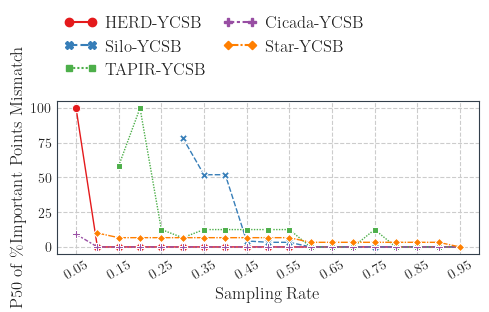

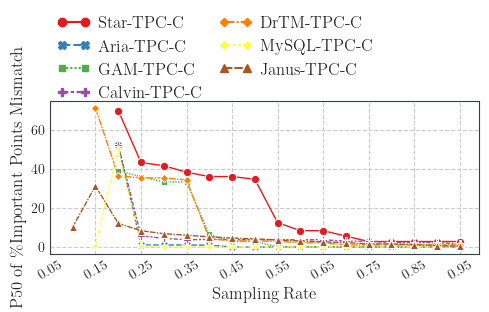

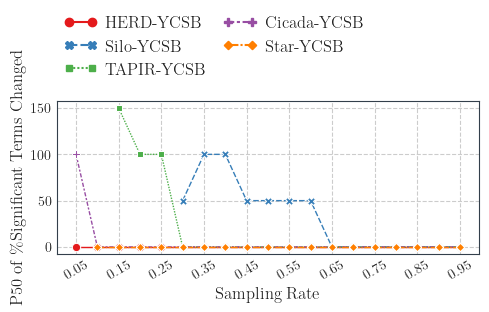

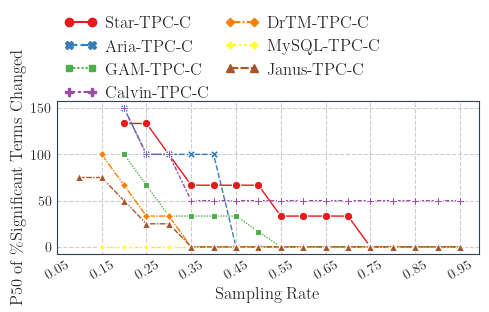

In [51]:
out_base = f"/ANOVA/plots/anova" # need to change accordingly
if not os.path.exists(out_base):
    os.makedirs(out_base)

fig_size_one = set_size(WIDTH)


for metric in ["num_turning_mismatch","num_of_terms_changed"]:
    for is_ycsb in [True,False]:
        df_subset_idx = df['alg'].apply(lambda x: "YCSB" in x) == is_ycsb
        df_subset_idx &= df['sample_method']=="random"
        fig, ax = plt.subplots(1, 1, figsize=fig_size_one,constrained_layout=True)
        sns.lineplot(data=df[df_subset_idx],
                        x="sample_ratio",
                        y= metric ,
                        estimator="median",
                        palette="Set1",
                        errorbar = None,
                        # errorbar=("pi",60), 
                        # err_style="bars",
                        dashes=True, 
                        ax=ax,
                        hue="alg",
                        style = "alg",
                        markers = True,
                        linewidth=1.0)
        ax.set_xticks(np.arange(0.05, 1, 0.1))
        ax.set_xticklabels([f"{i:.2f}" for i in np.arange(0.05, 1, 0.1)],rotation=30)
        ax.set_xlabel("Sampling Rate")
        # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, borderaxespad=0.,numpoints=2)
        ax.legend(loc='upper left', bbox_to_anchor=(0., 1.6), ncol=2, borderaxespad=0.,numpoints=2)
        if metric == "num_turning_mismatch":
            ax.set_ylabel("P50 of \%Important Points Mismatch")
        else:
            ax.set_ylabel("P50 of \%Significant Terms Changed")
        if is_ycsb:
            fig.savefig(f"{out_base}/{metric}_ycsb.pdf",bbox_inches = 'tight',dpi=100,format='pdf')
        else:
            fig.savefig(f"{out_base}/{metric}_tpc-c.pdf",bbox_inches = 'tight',dpi=100,format='pdf')

# fig.savefig(f"{out_base}/anova_r2_unsample.pdf",bbox_inches = 'tight',dpi=100,format='pdf')